In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%config InlineBackend.figure_format = 'retina'

In [2]:
A = [[2, 3], [-2, -3], [4, 5], [-4, -2], [4, 4], [-1, -3]]

In [3]:
B = [1, 0, 1, 0, 1, 0]

<Axes: >

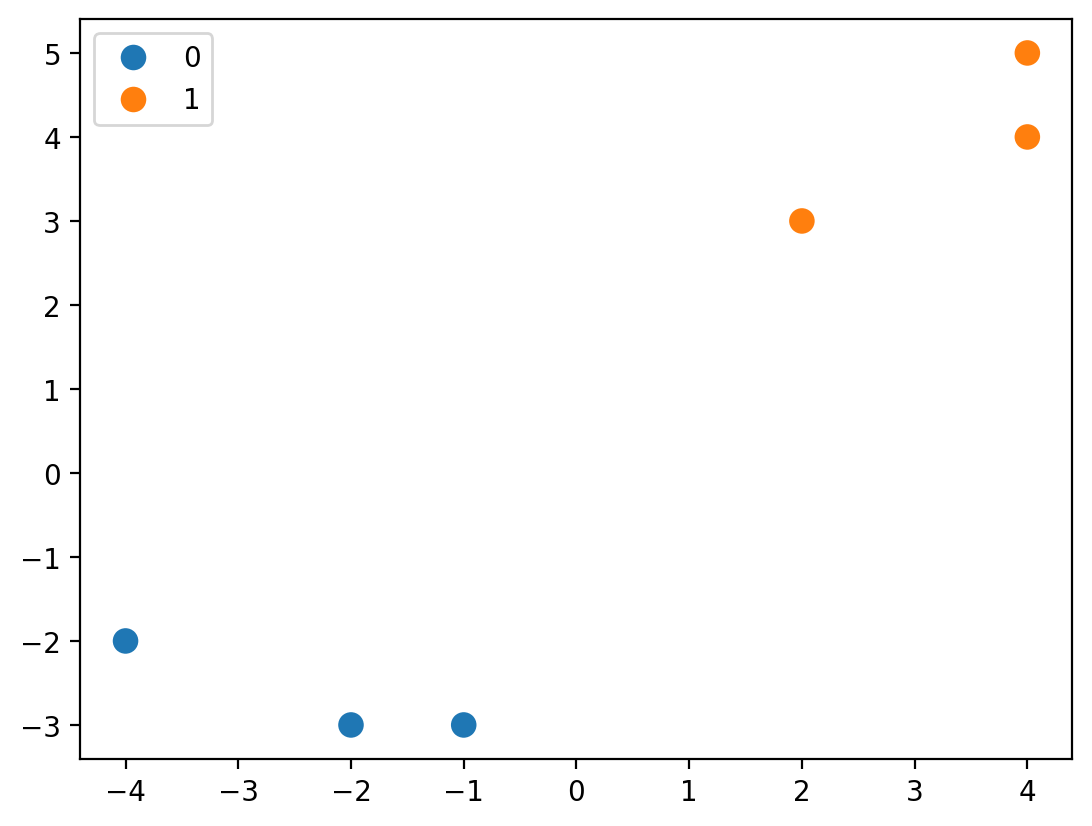

In [4]:
sns.scatterplot(x = np.array(A)[:, 0], y = np.array(A)[:, 1], hue = np.array(B), s = 100)

In [5]:
x = [4, 6]

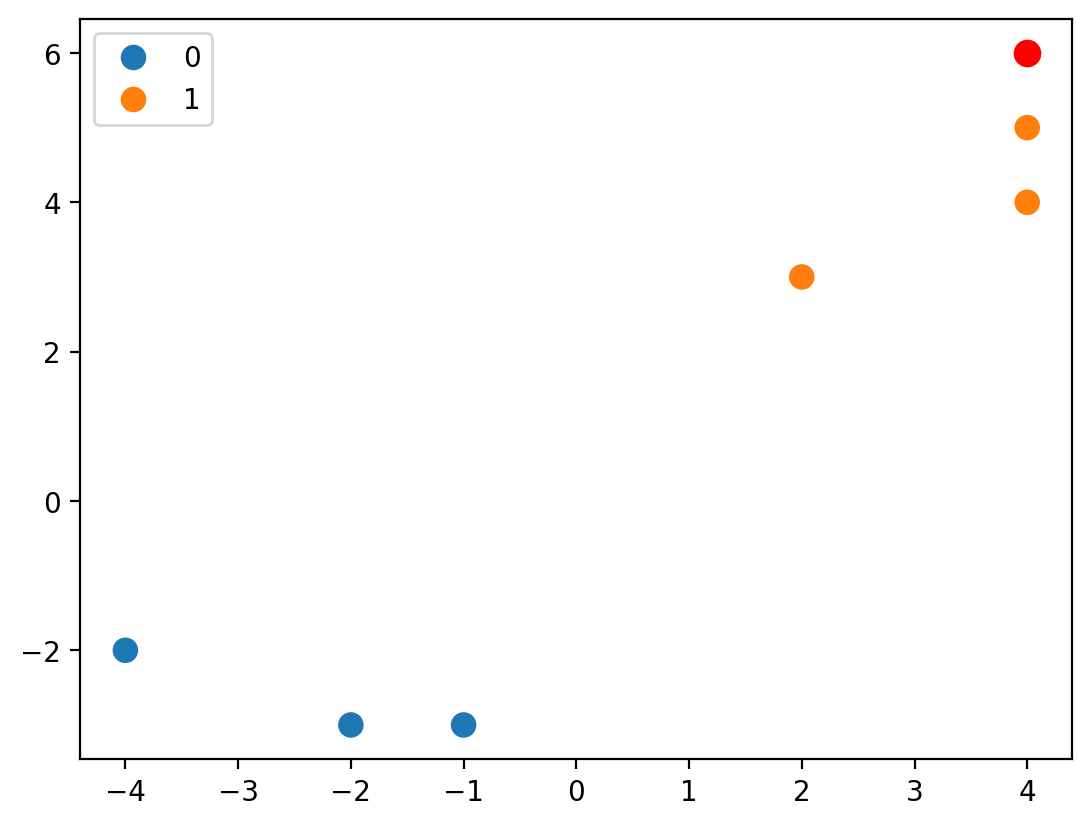

In [6]:
sns.scatterplot(x = np.array(A)[:, 0], y = np.array(A)[:, 1], hue = np.array(B), s = 100)
plt.scatter(x[0], x[1], c = 'red', s = 80)

In [7]:
data = np.hstack((np.array(A), np.array(B).reshape(-1, 1)))

In [8]:
data

array([[ 2,  3,  1],
       [-2, -3,  0],
       [ 4,  5,  1],
       [-4, -2,  0],
       [ 4,  4,  1],
       [-1, -3,  0]])

In [9]:
distances = [ ]

In [10]:
for i in range(0, len(data)):
        distances.append((np.sqrt((data[i][0] - x[0]) ** 2 + (data[i][1] - x[1]) ** 2), data[i][2]))

In [11]:
distances

[(np.float64(3.605551275463989), np.int64(1)),
 (np.float64(10.816653826391969), np.int64(0)),
 (np.float64(1.0), np.int64(1)),
 (np.float64(11.313708498984761), np.int64(0)),
 (np.float64(2.0), np.int64(1)),
 (np.float64(10.295630140987), np.int64(0))]

In [12]:
np.array(sorted(distances))

array([[ 1.        ,  1.        ],
       [ 2.        ,  1.        ],
       [ 3.60555128,  1.        ],
       [10.29563014,  0.        ],
       [10.81665383,  0.        ],
       [11.3137085 ,  0.        ]])

In [13]:
distances = np.array(sorted(distances))

In [14]:
classes = distances[:, 1][:3]

In [15]:
classes

array([1., 1., 1.])

In [16]:
count_0 = len(classes[classes == 0])
count_1 = len(classes[classes == 1])

In [17]:
count_1, count_0

(3, 0)

In [18]:
if count_1 > count_0:
  print('x is 1st class')
elif count_1 == count_0:
  print('Error: Number of classes are equal')
else:
  print('x is 0 class')

x is 1st class


In [19]:
def KNN(x, k_estimators, x_train, y_train):

    # Merging x and y train datasets
    data = np.hstack((np.array(x_train), np.array(y_train).reshape(-1, 1)))

    # Empty list for storing the distances
    distances = [ ]

    # Calcultaing the distance for each point in the dataset and appending them to list
    for i in range(0, len(data)):
        distances.append((np.sqrt((data[i][0] - x[0]) ** 2 + (data[i][1] - x[1]) ** 2), data[i][2]))

    # Sorting distances by ascending order
    distances = np.array(sorted(distances))

    # Selecting the classes of first k distances
    classes = distances[:, 1][:k_estimators]

    # Counters for zeros and ones
    count_0 = len(classes[classes == 0])
    count_1 = len(classes[classes == 1])

    if count_1 > count_0:
        return 'x is 1st class'
    elif count_1 == count_0:
        return('Error: Number of classes are equal')
    else:
        return 'x is 0 class'

In [20]:
KNN(x = [-7, 7], k_estimators = 5, x_train = A, y_train = B)

'x is 1st class'

In [21]:
KNN(x = [-7, 7], k_estimators = 6, x_train = A, y_train = B)

'Error: Number of classes are equal'

In [22]:
data = pd.read_csv('https://raw.githubusercontent.com/konansul/ml-projects/main/datasets/multiple_linear_regression_dataset.csv')

In [23]:
data

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


<Axes: xlabel='age', ylabel='experience'>

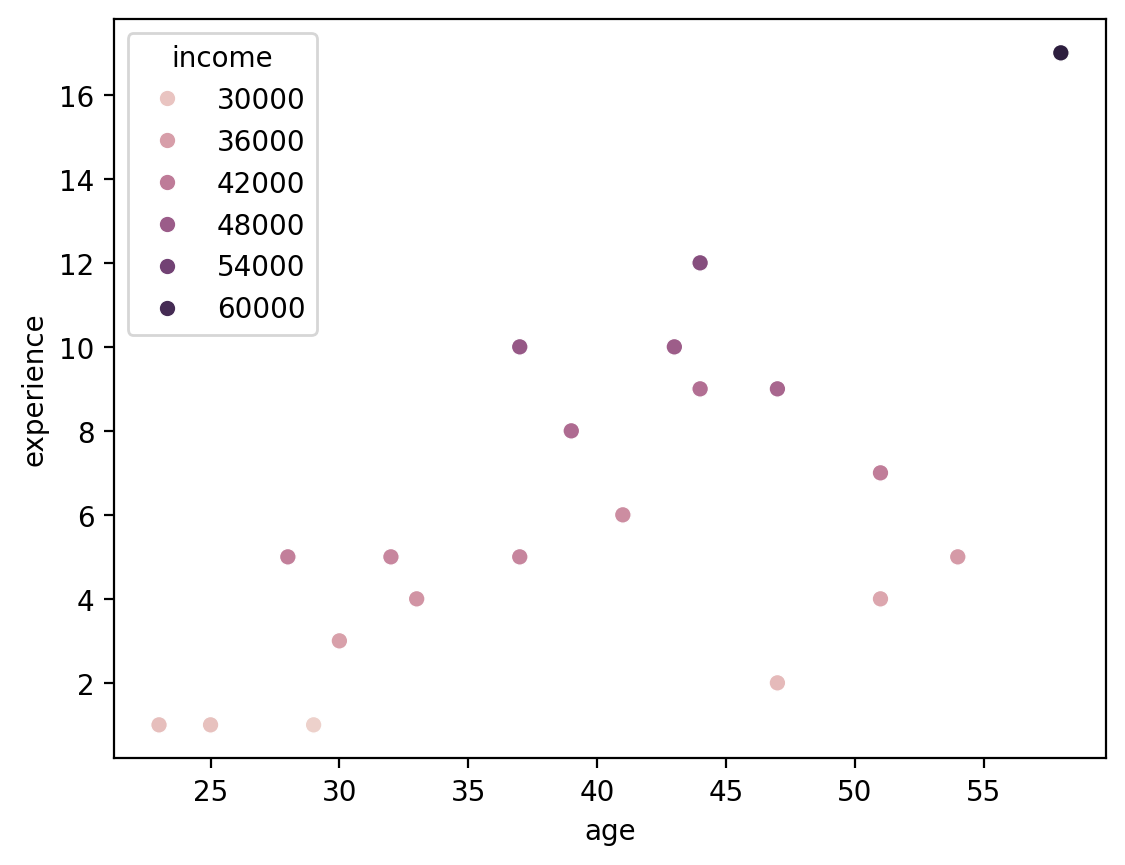

In [24]:
sns.scatterplot(x = 'age', y = 'experience', hue = 'income', data = data)

In [25]:
X = np.array(data[['age', 'experience']])

In [26]:
X

array([[25,  1],
       [30,  3],
       [47,  2],
       [32,  5],
       [43, 10],
       [51,  7],
       [28,  5],
       [33,  4],
       [37,  5],
       [39,  8],
       [29,  1],
       [47,  9],
       [54,  5],
       [51,  4],
       [44, 12],
       [41,  6],
       [58, 17],
       [23,  1],
       [44,  9],
       [37, 10]])

In [27]:
y = np.array(data['income'])

In [28]:
y

array([30450, 35670, 31580, 40130, 47830, 41630, 41340, 37650, 40250,
       45150, 27840, 46110, 36720, 34800, 51300, 38900, 63600, 30870,
       44190, 48700])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [30]:
X_test[0]

array([44,  9])

In [31]:
x = [50, 14]

In [32]:
distances = [ ]

In [33]:
for i in range(0, len(X_train)):
        distances.append((np.sqrt((X_train[i][0] - X_test[0][0]) ** 2 + (X_train[i][1] - X_test[0][1]) ** 2), y_train[i]))

In [34]:
len(distances)

15

In [35]:
np.array(sorted(distances))

array([[1.41421356e+00, 4.78300000e+04],
       [3.00000000e+00, 4.61100000e+04],
       [3.00000000e+00, 5.13000000e+04],
       [4.24264069e+00, 3.89000000e+04],
       [5.09901951e+00, 4.51500000e+04],
       [7.28010989e+00, 4.16300000e+04],
       [7.61577311e+00, 3.15800000e+04],
       [8.60232527e+00, 3.48000000e+04],
       [1.07703296e+01, 3.67200000e+04],
       [1.20830460e+01, 3.76500000e+04],
       [1.26491106e+01, 4.01300000e+04],
       [1.61245155e+01, 6.36000000e+04],
       [1.64924225e+01, 4.13400000e+04],
       [2.06155281e+01, 3.04500000e+04],
       [2.24722051e+01, 3.08700000e+04]])

In [36]:
distances = np.array(sorted(distances))

In [37]:
classes = distances[:, 1][:5]

In [38]:
classes

array([47830., 46110., 51300., 38900., 45150.])

In [39]:
np.mean(classes)

np.float64(45858.0)

In [40]:
y_test[0]

np.int64(44190)

In [41]:
np.mean(distances[:, 1][:10])

np.float64(41167.0)

In [42]:
error = np.mean(classes) - y_test[0]

In [43]:
error

np.float64(1668.0)

In [44]:
np.mean(distances[:, 1][:10]) - y_test[0]

np.float64(-3023.0)